# Проект по обнаружению мусора на изображениях/видео с помощью YOLO

Мусор - серьезная проблема для нашего общества и окружающей среды. Именно поэтому обнаружение мусора приобретает все большее значение, поскольку мы стремимся сохранить окружающую среду чистой и безопасной. Обнаружение и удаление отходов в общественных местах и частных владениях имеет решающее значение для поддержания гигиены и снижения уровня загрязнения.



Однако отслеживать отходы на больших территориях вручную может быть сложно и отнимать много времени. Именно здесь на помощь приходят модели глубокого обучения, такие как YOLO (You Only Look Once), позволяющие в режиме реального времени обнаруживать мусор на изображениях и видео.



Используем модель обнаружения объектов YOLOv8 для обнаружения мусора на изображениях и видео в реальном времени. Мы рассмотрим, как методы компьютерного зрения с помощью OpenCV и YOLO могут упростить процесс обнаружения мусора.



Этот проект включает в себя две программы на Python: одну для обнаружения мусора на изображениях и другую для обнаружения мусора на видео в режиме реального времени.

# Установка пакетов и зависимостей

Загрузим все необходимые нам зависимости с помощью следующих команд:

In [ ]:
!pip install gitpython>=3.1.30
!pip install matplotlib>=3.3
!pip install numpy>=1.23.5
!pip install opencv-python>=4.1.1
!pip install pillow>=10.3.0
!pip install psutil
!pip install PyYAML>=5.3.1
!pip install requests>=2.32.0
!pip install scipy>=1.4.1
!pip install thop>=0.1.1
!pip install torch>=1.8.0
!pip install torchvision>=0.9.0
!pip install tqdm>=4.64.0
!pip install ultralytics>=8.2.34
!pip install pandas>=1.1.4
!pip install seaborn>=0.11.0
!pip install setuptools>=65.5.1
!pip install filterpy
!pip install scikit-image
!pip install lap
!pip install ultralytics
!pip install cvzone

# Импорт библиотек

In [ ]:
# Работа с операционной системой (файлы, переменные окружения)
import os

# Компьютерное сзрение
import cv2

# Пакет для компьютерного зрения для выполнения функций обработки изображений и искусственного интеллекта
import cvzone

# Стандартные математические функции и константы
import math

# Для генерации случайных чисел
import random

# Модуль линейной алгебры
import numpy as np

# Для работы с данными
import pandas as pd

# Предобученная модель YOLO
from ultralytics import YOLO

# Коннект гугл диска
from google.colab import drive

# Работа с изображениями (Pillow)
from PIL import Image

# Для отображения изображений в гугл колаб
from IPython.display import Image, display

# Для подключения файлов из колаба
from google.colab import files

# Патч для функционирования cv2_imshow в колабе
from google.colab.patches import cv2_imshow

# Работа с графиками
import matplotlib.pyplot as plt
%matplotlib inline

# Отключаем лишние предупреждения
import warnings
warnings.filterwarnings('ignore')

# Загрузка датасета

Используем garbage_best.v1i.yolov8-obb с сайте [Roboflow](https://universe.roboflow.com/smart-india-hackathon-2023/garbage_best).

Этот набор данных содержит изображения в формате YOLO c ориентированными ограничительными рамками для классификации и обнаружения 6 классов мусора. Содержит 2483 изображения.

Загрузим датасет с Google Drive:

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# Обучение YOLO

In [ ]:
!nvidia-smi

Sat May 31 04:31:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Теперь мы начнем обучение нашей модели YOLO на наборе данных для обнаружения мусора.

Здесь 'epochs=50' задает количество эпох обучения. Эпоха - это один полный проход по всему обучающему набору данных. Здесь модель будет обучаться в течение 50 эпох.

'imgsz=640' задает размер входных изображений, на которых будет обучаться модель. В данном случае изображения будут изменены до размера 640×640 пикселей перед подачей в модель.

plots=True генерирует и сохраняет графики показателей обучения и проверки, а также примеры предсказаний, обеспечивая визуальное представление о производительности модели и прогрессе обучения.

In [ ]:
!yolo task=detect mode=train model=yolov8l.pt data=../content/drive/MyDrive/Datasets/GarbageDetection/data.yaml epochs=50 imgsz=640 plots=True

# Результаты обучения

Отображение labels.jpg:


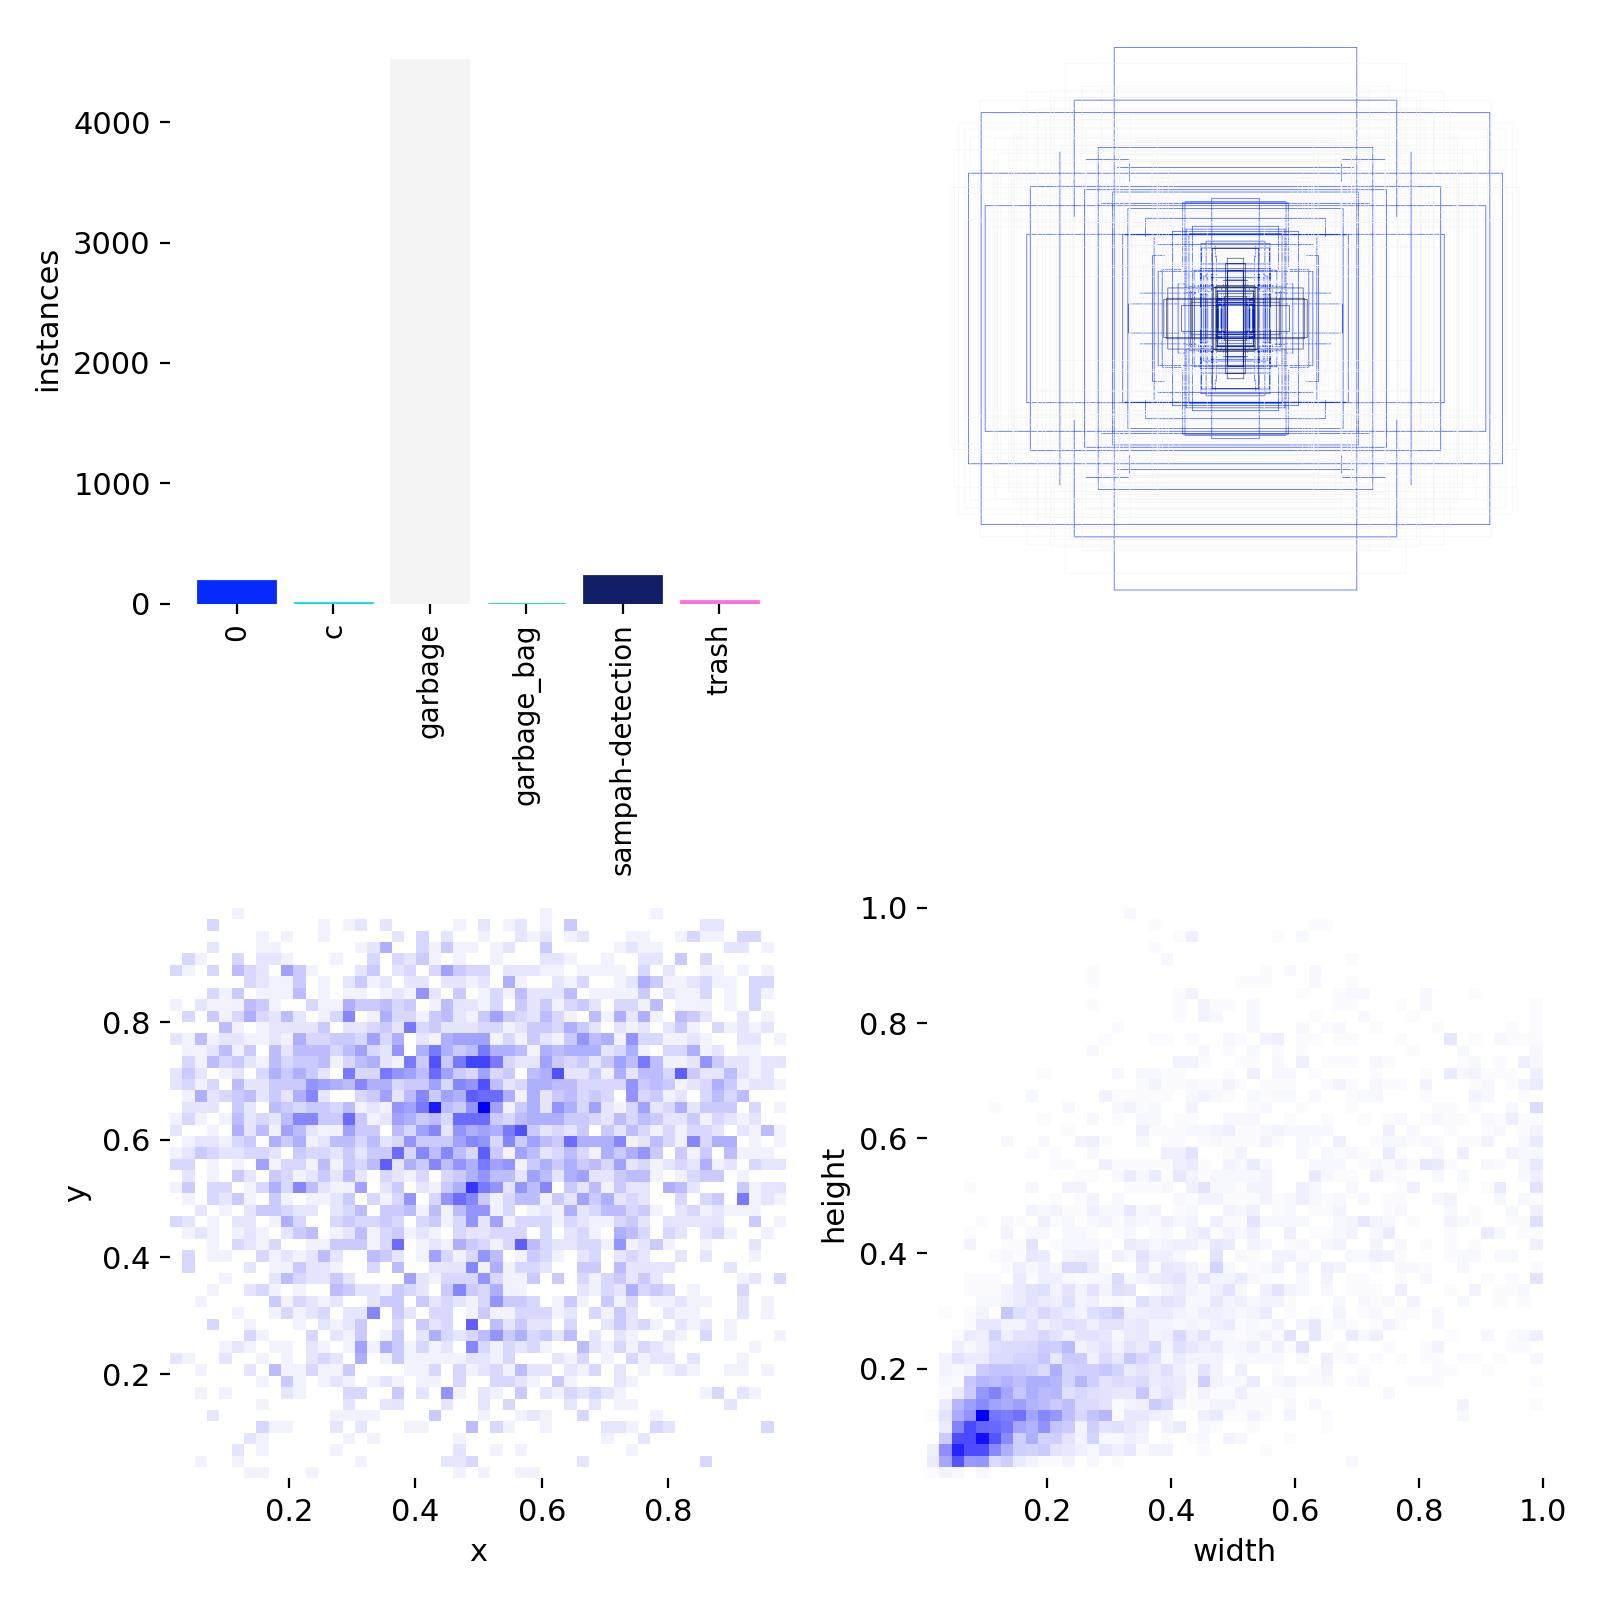


Отображение labels_correlogram.jpg:


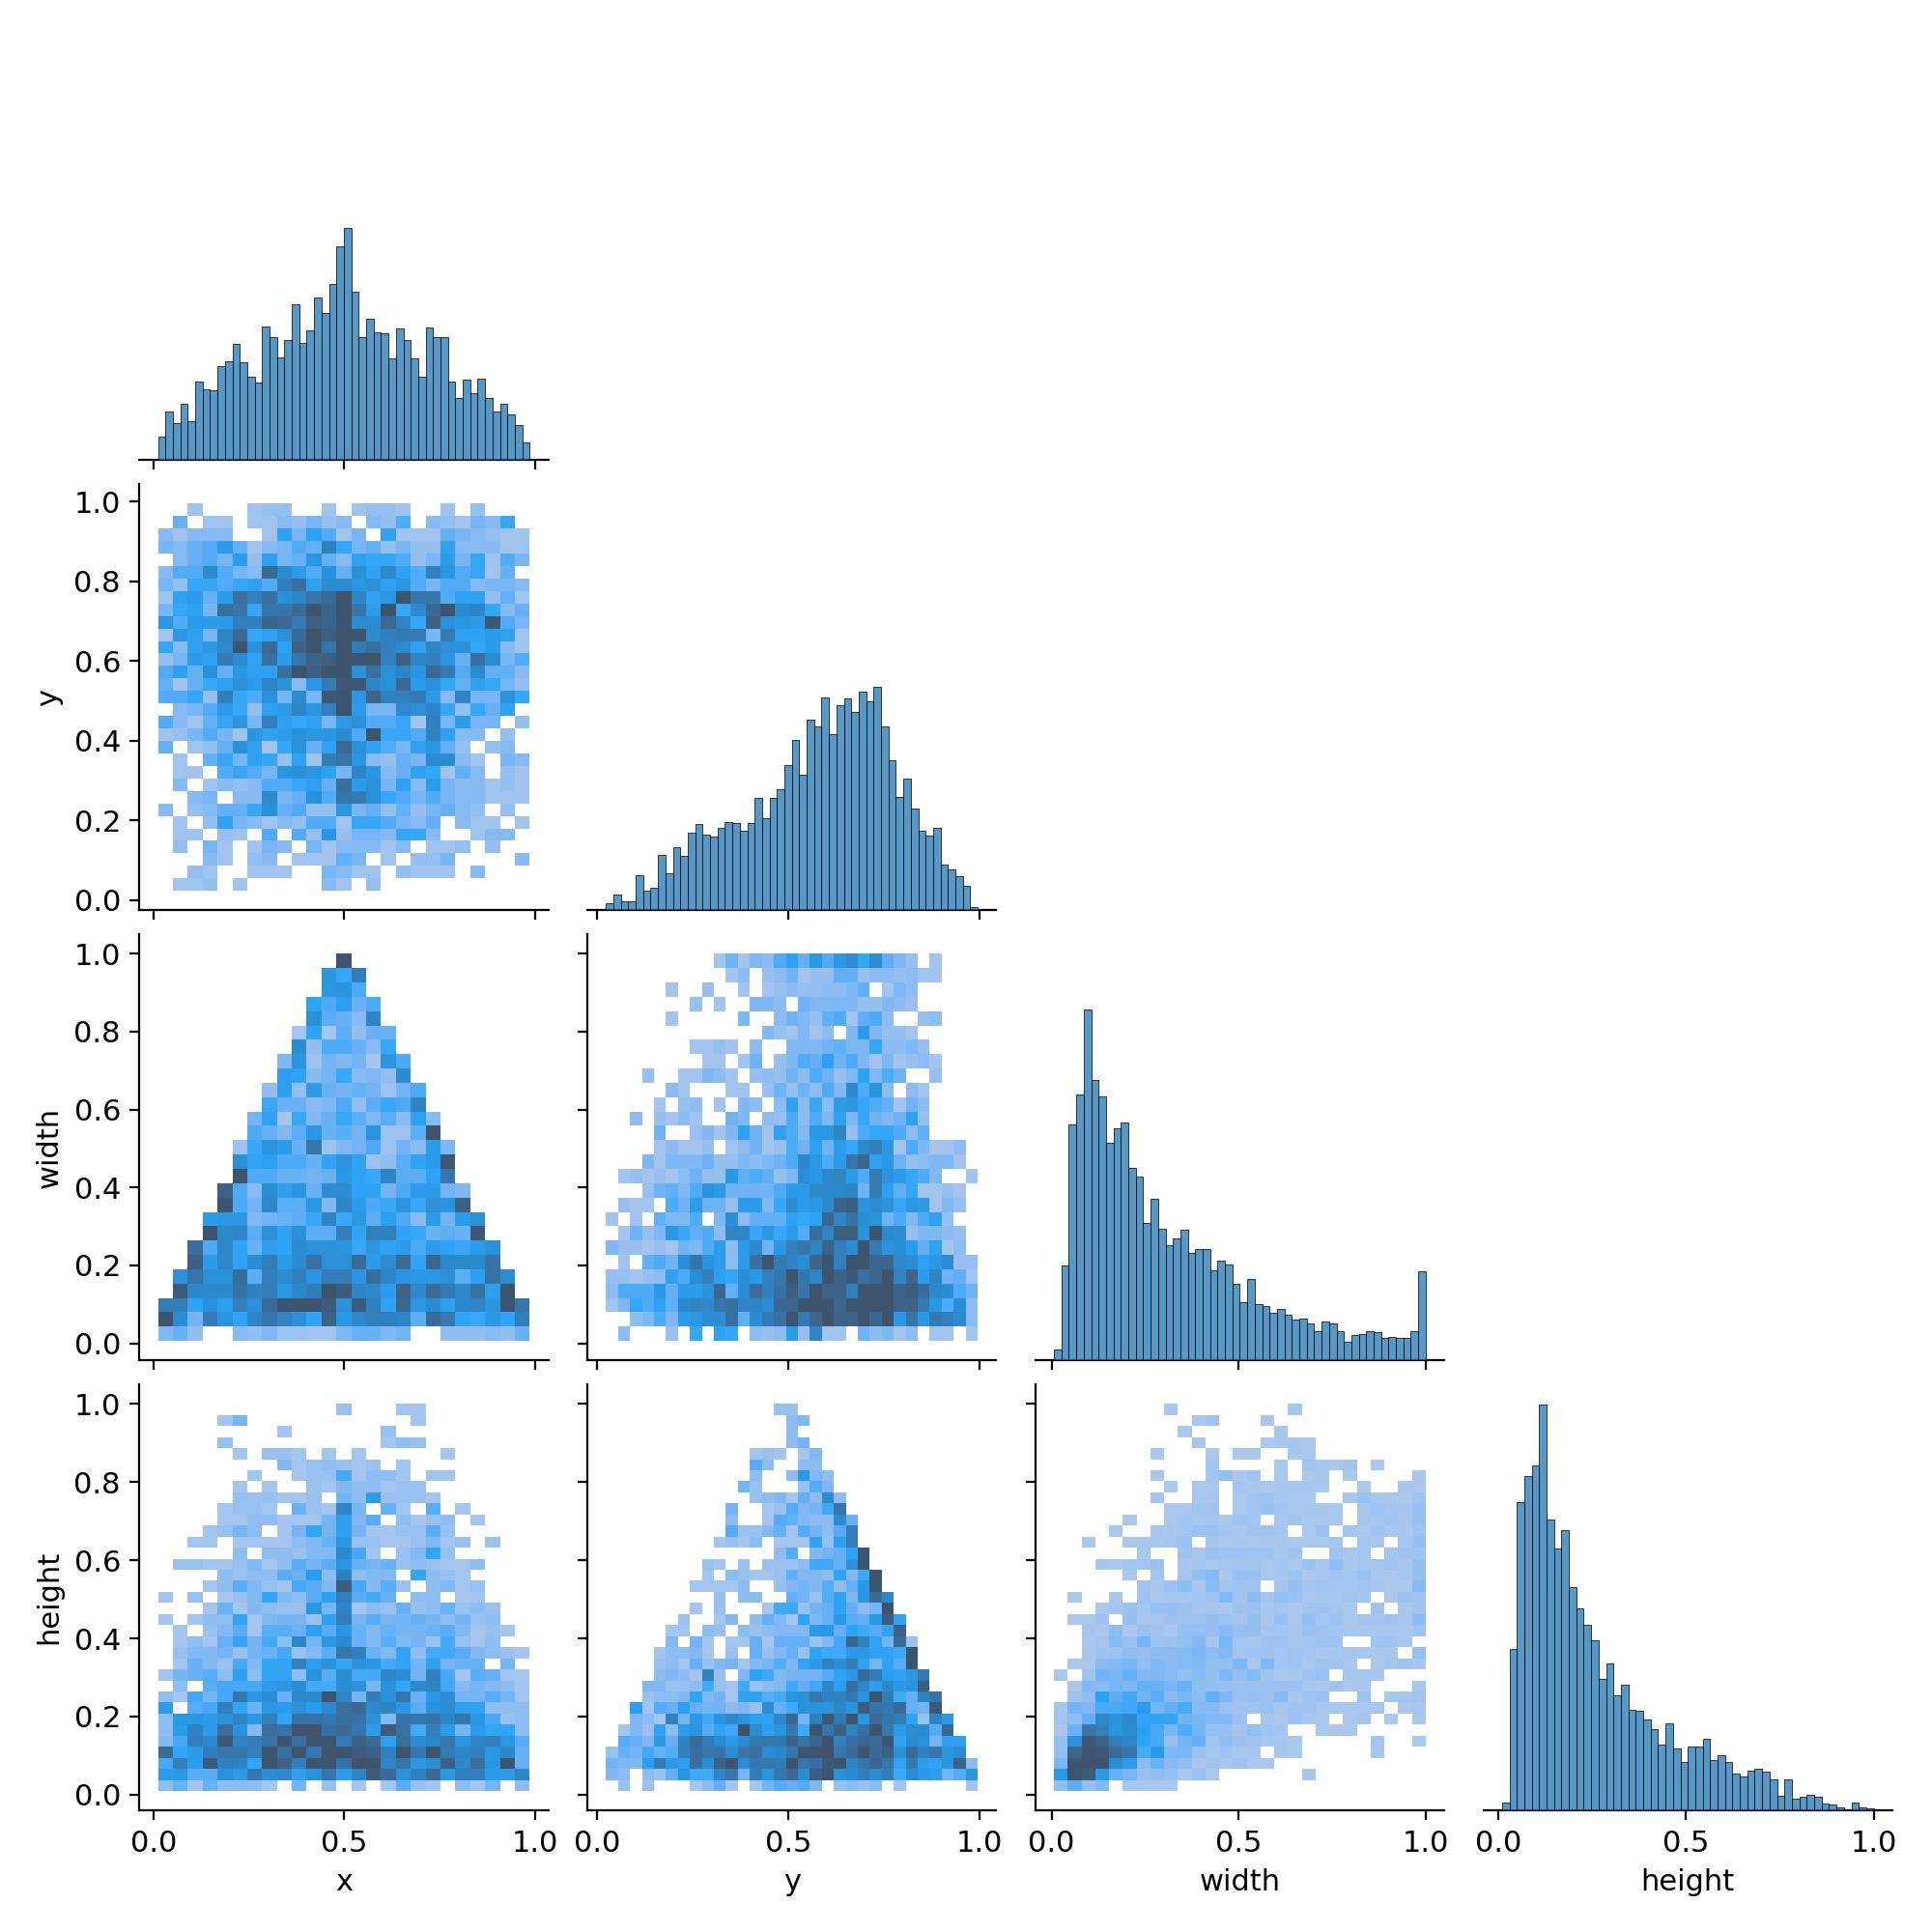

In [ ]:
def display_images(image_dir='.'):
    """
    Отображает изображения labels.jpg и labels_correlogram.jpg из указанной директории.

    Args:
        image_dir (str): Путь к директории с изображениями. По умолчанию текущая директория.
    """
    # Проверяем существование файлов
    labels_path = os.path.join(image_dir, 'labels.jpg')
    correlogram_path = os.path.join(image_dir, 'labels_correlogram.jpg')

    if not os.path.exists(labels_path):
        print(f"Файл {labels_path} не найден!")
    else:
        print("Отображение labels.jpg:")
        display(Image(filename=labels_path))

    if not os.path.exists(correlogram_path):
        print(f"Файл {correlogram_path} не найден!")
    else:
        print("\nОтображение labels_correlogram.jpg:")
        display(Image(filename=correlogram_path))

# Использование:
display_images('/content/runs/detect/train')

In [ ]:
def display_results_table(csv_path='results.csv'):
    """
    Считывает CSV-файл с результатами обучения и отображает его в виде таблицы в Colab.

    Args:
        csv_path (str): Путь к CSV-файлу с результатами. По умолчанию 'results.csv'.
    """
    try:
        # Чтение CSV-файла
        df = pd.read_csv(csv_path)

        # Отображение таблицы с полосой прокрутки, если столбцов много
        display(df)

        print(f"\nДанные успешно загружены из файла: {csv_path}")
        print(f"Всего строк: {len(df)}, столбцов: {len(df.columns)}")

    except FileNotFoundError:
        print(f"Ошибка: файл {csv_path} не найден!")
    except Exception as e:
        print(f"Произошла ошибка при чтении файла: {str(e)}")

In [ ]:
display_results_table('/content/runs/detect/train/results.csv')

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,588.970,1.73844,2.54396,1.87753,0.42999,0.03392,0.01518,0.00613,2.59992,8.40317,2.78343,0.000330,0.000330,0.000330
1,2,695.330,1.89525,2.40277,2.03019,0.02565,0.17499,0.02286,0.00847,2.14347,14.07750,2.46979,0.000650,0.000650,0.000650
2,3,794.770,1.91865,2.43892,2.04143,0.01089,0.22120,0.00968,0.00395,2.27394,30.46390,2.60536,0.000957,0.000957,0.000957
3,4,893.154,1.87095,2.39211,1.98922,0.63401,0.05426,0.03906,0.01459,2.09971,3.95800,2.32378,0.000941,0.000941,0.000941
4,5,992.110,1.84949,2.33565,1.95493,0.44506,0.06614,0.05959,0.02477,1.97613,3.32080,2.19489,0.000921,0.000921,0.000921
5,6,1090.410,1.79643,2.22782,1.92778,0.44850,0.05743,0.04993,0.02032,1.94691,3.34985,2.10087,0.000901,0.000901,0.000901
6,7,1186.730,1.78640,2.23895,1.91181,0.65626,0.06812,0.07060,0.02984,2.00250,2.98123,2.12817,0.000881,0.000881,0.000881
7,8,1284.180,1.73120,2.20689,1.87853,0.46339,0.07010,0.07758,0.03282,1.94763,2.91897,2.08192,0.000861,0.000861,0.000861
8,9,1382.050,1.73416,2.17332,1.85389,0.66478,0.06614,0.07121,0.03102,1.91120,2.88184,2.03680,0.000842,0.000842,0.000842
9,10,1478.610,1.68093,2.09996,1.82676,0.65955,0.06574,0.08134,0.03545,1.90259,2.91172,2.05901,0.000822,0.000822,0.000822



Данные успешно загружены из файла: /content/runs/detect/train/results.csv
Всего строк: 50, столбцов: 15


In [ ]:
def plot_training_results(csv_path='/content/runs/detect/train/results.csv', num_epochs=50):
    """
    Строит графики метрик обучения из CSV-файла с результатами

    Args:
        csv_path (str): Путь к CSV-файлу с результатами
        num_epochs (int): Количество эпох для отображения
    """
    try:
        # Чтение данных
        df = pd.read_csv(csv_path)

        # Ограничиваем количество эпох
        df = df.head(num_epochs)

        # Создаем фигуру с несколькими subplots
        plt.figure(figsize=(15, 12))

        # График 1: Loss функции
        plt.subplot(2, 2, 1)
        plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
        plt.plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss')
        plt.plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss')
        plt.plot(df['epoch'], df['val/box_loss'], '--', label='Val Box Loss')
        plt.plot(df['epoch'], df['val/cls_loss'], '--', label='Val Class Loss')
        plt.plot(df['epoch'], df['val/dfl_loss'], '--', label='Val DFL Loss')
        plt.title('Training & Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        # График 2: Precision и Recall
        plt.subplot(2, 2, 2)
        plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
        plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
        plt.title('Precision & Recall')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)

        # График 3: mAP
        plt.subplot(2, 2, 3)
        plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5')
        plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
        plt.title('mAP Metrics')
        plt.xlabel('Epoch')
        plt.ylabel('mAP')
        plt.legend()
        plt.grid(True)

        # График 4: Время обучения
        plt.subplot(2, 2, 4)
        plt.plot(df['epoch'], df['time'], label='Time per epoch')
        plt.title('Training Time')
        plt.xlabel('Epoch')
        plt.ylabel('Time (s)')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

        print(f"Успешно построены графики для {len(df)} эпох")

    except FileNotFoundError:
        print(f"Ошибка: файл {csv_path} не найден!")
    except Exception as e:
        print(f"Произошла ошибка: {str(e)}")

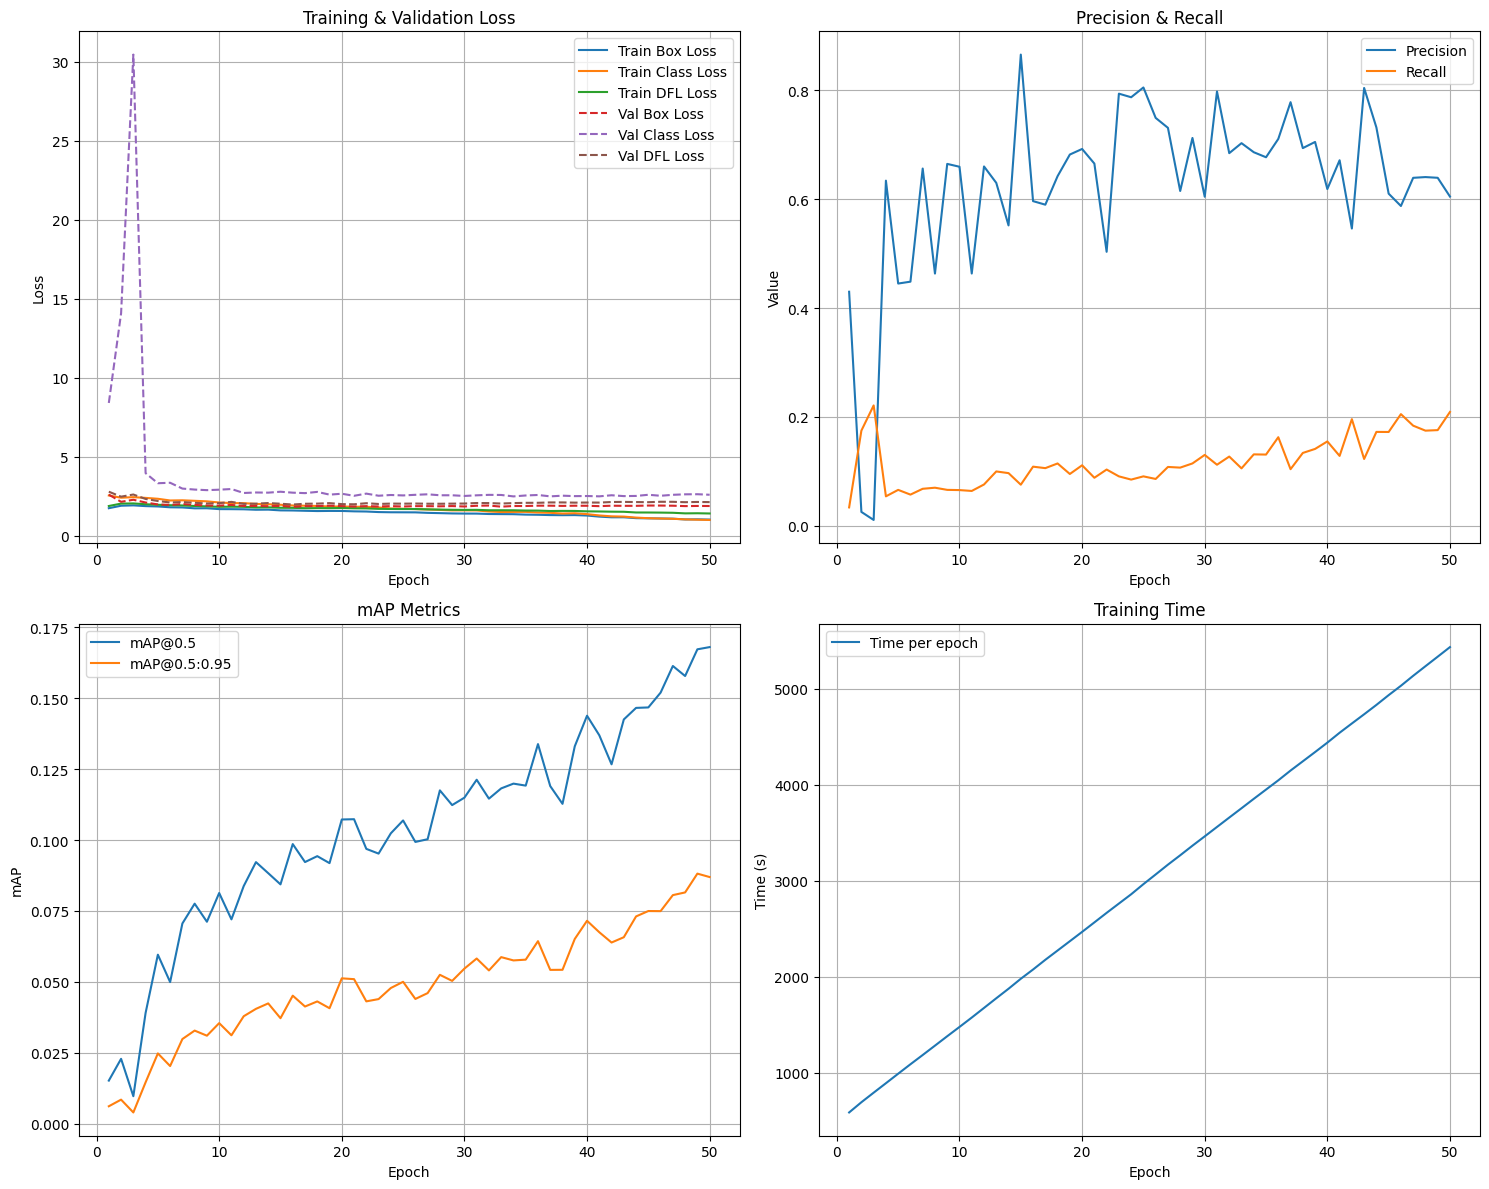

Успешно построены графики для 50 эпох


In [ ]:
plot_training_results('/content/runs/detect/train/results.csv', 50)

# Инференс модели

## Загрузка модели YOLO и определение имен классов

Затем загрузим модель YOLO с обученными весами и определим имена классов, которые YOLO может обнаружить.

In [ ]:
# Загрузка модели YOLO с кастомными весами
yolo_model = YOLO("/content/best.pt")

# Определение имен классов
class_labels = ['0', 'c', 'garbage', 'garbage_bag', 'sampah-detection', 'trash']

## Загрузка изображений

Теперь загрузим изображение для обработки, используя метод OpenCV 'imread'.

In [ ]:
image_path = "/content/GarbageDetector/Media/garbage_1.jpg"
img = cv2.imread(image_path)

## Обнаружение объектов

Далее используем 'yolo_model' для обнаружения объектов на загруженном изображении.

In [ ]:
results = yolo_model(img)


0: 448x640 2 garbages, 2 sampah-detections, 130.9ms
Speed: 3.7ms preprocess, 130.9ms inference, 413.8ms postprocess per image at shape (1, 3, 448, 640)


## Отображение рамок и меток

Теперь мы пройдемся по обнаруженным объектам и нарисуем вокруг них ограничительные рамки. Также будут отображены оценка вероятности предсказания и метка класса.

In [ ]:
for r in results:
    boxes = r.boxes
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0]
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        w, h = x2 - x1, y2 - y1

        conf = math.ceil((box.conf[0] * 100)) / 100
        cls = int(box.cls[0])

        if conf > 0.3:
            cvzone.cornerRect(img, (x1, y1, w, h), t=2)
            cvzone.putTextRect(img, f'{class_labels[cls]} {conf}', (x1, y1 - 10), scale=0.8, thickness=1, colorR=(255, 0, 0))

## Отображение изображения

Наконец, мы выведем обработанное изображение на экран с помощью метода OpenCV 'imshow'. Окно закроется при нажатии кнопки 'q'.

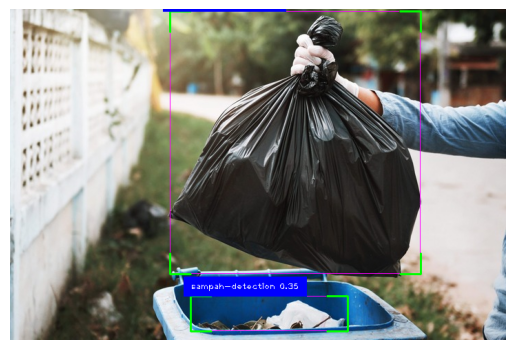

In [ ]:
# Отображаем изображение
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Конвертируем BGR (OpenCV) в RGB (Matplotlib)
plt.axis('off')  # Скрываем оси
plt.show()  # Показываем изображение

Функция отображения:

In [ ]:
def detect_and_show_images(yolo_model, image_paths, class_labels, conf_threshold=0.3):
    """
    Обрабатывает и отображает несколько изображений с детекциями YOLO

    Параметры:
        yolo_model: YOLO модель
        image_paths: список путей к изображениям
        class_labels: список меток классов
        conf_threshold: порог уверенности для отображения (по умолчанию 0.3)
    """
    num_images = len(image_paths)
    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))

    if num_images == 1:
        axes = [axes]  # Чтобы можно было итерировать даже для одного изображения

    for ax, image_path in zip(axes, image_paths):
        # Загрузка и обработка изображения
        img = cv2.imread(image_path)
        if img is None:
            print(f"Ошибка: не удалось загрузить изображение {image_path}!")
            continue

        # Детекция объектов
        results = yolo_model(img)
        for r in results:
            boxes = r.boxes
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0]
                x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
                w, h = x2 - x1, y2 - y1

                conf = math.ceil((box.conf[0] * 100)) / 100
                cls = int(box.cls[0])

                if conf > conf_threshold:
                    cvzone.cornerRect(img, (x1, y1, w, h), t=2)
                    cvzone.putTextRect(img, f'{class_labels[cls]} {conf}',
                                     (x1, y1 - 10), scale=0.8, thickness=1, colorR=(255, 0, 0))

        # Отображение
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        ax.set_title(image_path.split('/')[-1])  # Показываем имя файла

    plt.tight_layout()
    plt.show()


0: 448x640 2 garbages, 2 sampah-detections, 49.8ms
Speed: 3.5ms preprocess, 49.8ms inference, 2.1ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 garbage, 49.7ms
Speed: 3.1ms preprocess, 49.7ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 7 garbages, 42.2ms
Speed: 3.8ms preprocess, 42.2ms inference, 3.8ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 6 garbages, 35.5ms
Speed: 4.3ms preprocess, 35.5ms inference, 2.3ms postprocess per image at shape (1, 3, 448, 640)

0: 480x640 5 garbages, 75.2ms
Speed: 3.5ms preprocess, 75.2ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


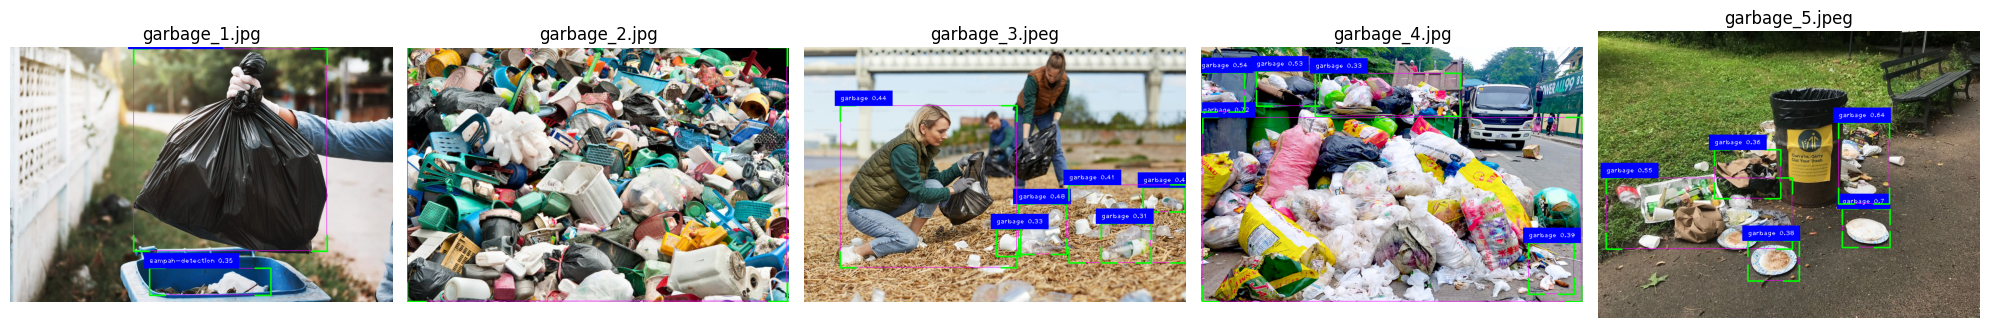

In [ ]:
image_paths = [
    "/content/GarbageDetector/Media/garbage_1.jpg",
    "/content/GarbageDetector/Media/garbage_2.jpg",
    "/content/GarbageDetector/Media/garbage_3.jpeg",
    "/content/GarbageDetector/Media/garbage_4.jpg",
    "/content/GarbageDetector/Media/garbage_5.jpeg"
]

detect_and_show_images(yolo_model, image_paths, class_labels)

In [ ]:
def plot_comparison_grid(yolo_model, images_dir, labels_dir, class_labels, num_images=10, conf_threshold=0.3):
    """
    Отображает сетку сравнения: оригинал vs GT vs предсказание

    Параметры:
        yolo_model: обученная YOLO модель
        images_dir: путь к папке с изображениями
        labels_dir: путь к папке с аннотациями
        class_labels: список классов
        num_images: количество изображений (по умолчанию 10)
        conf_threshold: порог уверенности (по умолчанию 0.3)
    """
    W, H = 640, 640
    # Получаем список изображений
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    selected_images = random.sample(image_files, min(num_images, len(image_files)))

    # Создаем фигуру (10 строк, 3 столбца)
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5*num_images))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)

    for row, img_name in enumerate(selected_images):
        img_path = os.path.join(images_dir, img_name)
        label_path = os.path.join(labels_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))

        # Загрузка изображения
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 1. Оригинальное изображение
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f"Original\n{img_name}", fontsize=8)
        axes[row, 0].axis('off')

        # 2. Ground Truth (обрабатываем несколько bbox в одной строке)
        gt_img = img_rgb.copy()
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    values = list(map(float, line.strip().split()))
                    # Обрабатываем по 9 значений на каждый bbox (class_id + 8 координат)
                    for i in range(0, len(values), 9):
                        if i + 8 >= len(values):
                            break  # Недостаточно значений для bbox

                        cls = int(values[i])
                        # Получаем все координаты точек
                        points = values[i+1:i+9]
                        # Преобразуем в список пар (x, y)
                        coords = [(points[j], points[j+1]) for j in range(0, 8, 2)]

                        # Находим минимальные и максимальные координаты для прямоугольника
                        x_coords = [x for x, y in coords]
                        y_coords = [y for x, y in coords]
                        x1 = int(min(x_coords) * W)  # W - ширина изображения
                        y1 = int(min(y_coords) * H)  # H - высота изображения
                        x2 = int(max(x_coords) * W)
                        y2 = int(max(y_coords) * H)

                        # Рисуем GT bounding box
                        cv2.rectangle(gt_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                        cv2.putText(gt_img, f'{class_labels[cls]}',
                                  (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        axes[row, 1].imshow(gt_img)
        axes[row, 1].set_title("Ground Truth", fontsize=8)
        axes[row, 1].axis('off')

        # 3. Предсказания модели
        pred_img = img_rgb.copy()
        results = yolo_model(img)

        total_iou = 0
        detected_boxes = 0

        for r in results:
            boxes = r.boxes
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0]
                x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
                w, h = x2 - x1, y2 - y1

                conf = math.ceil((box.conf[0] * 100)) / 100
                cls = int(box.cls[0])

                if conf > conf_threshold:
                    # Рисуем предсказанный bbox
                    cvzone.cornerRect(pred_img, (x1, y1, w, h), l=15, t=2, colorR=(255, 0, 0))
                    cvzone.putTextRect(pred_img, f'{class_labels[cls]} {conf}',
                                     (x1, y1-10), scale=0.6, thickness=1, colorR=(255, 0, 0))

                    # Рассчитываем IoU если есть GT
                    if os.path.exists(label_path):
                        with open(label_path, 'r') as f:
                            for gt_line in f.readlines():
                                gt_values = list(map(float, gt_line.strip().split()))
                                for i in range(0, len(gt_values), 5):
                                    if i + 4 >= len(gt_values):
                                        break

                                    gt_cls, gt_x, gt_y, gt_w, gt_h = gt_values[i], gt_values[i+1], gt_values[i+2], gt_values[i+3], gt_values[i+4]
                                    H, W = img.shape[:2]
                                    gt_x1 = int((gt_x - gt_w/2) * W)
                                    gt_y1 = int((gt_y - gt_h/2) * H)
                                    gt_x2 = int((gt_x + gt_w/2) * W)
                                    gt_y2 = int((gt_y + gt_h/2) * H)

                                    # Вычисляем IoU
                                    xi1 = max(x1, gt_x1)
                                    yi1 = max(y1, gt_y1)
                                    xi2 = min(x2, gt_x2)
                                    yi2 = min(y2, gt_y2)

                                    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
                                    pred_area = (x2 - x1) * (y2 - y1)
                                    gt_area = (gt_x2 - gt_x1) * (gt_y2 - gt_y1)

                                    iou = inter_area / (pred_area + gt_area - inter_area + 1e-6)
                                    total_iou += iou
                                    detected_boxes += 1

        avg_iou = total_iou / detected_boxes if detected_boxes > 0 else 0
        axes[row, 2].imshow(pred_img)
        axes[row, 2].set_title(f"Predictions\nAvg IoU: {avg_iou:.2f}", fontsize=8)
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()


0: 640x640 1 garbage, 62.7ms
Speed: 4.5ms preprocess, 62.7ms inference, 334.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 garbages, 62.7ms
Speed: 4.0ms preprocess, 62.7ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 garbage, 1 sampah-detection, 64.5ms
Speed: 14.0ms preprocess, 64.5ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 garbages, 64.5ms
Speed: 3.5ms preprocess, 64.5ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 garbage, 68.9ms
Speed: 3.5ms preprocess, 68.9ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 garbages, 62.8ms
Speed: 3.7ms preprocess, 62.8ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 garbages, 62.7ms
Speed: 4.0ms preprocess, 62.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 garbages, 62.7ms
Speed: 3.5ms preprocess, 62.7ms inference, 1.9ms post

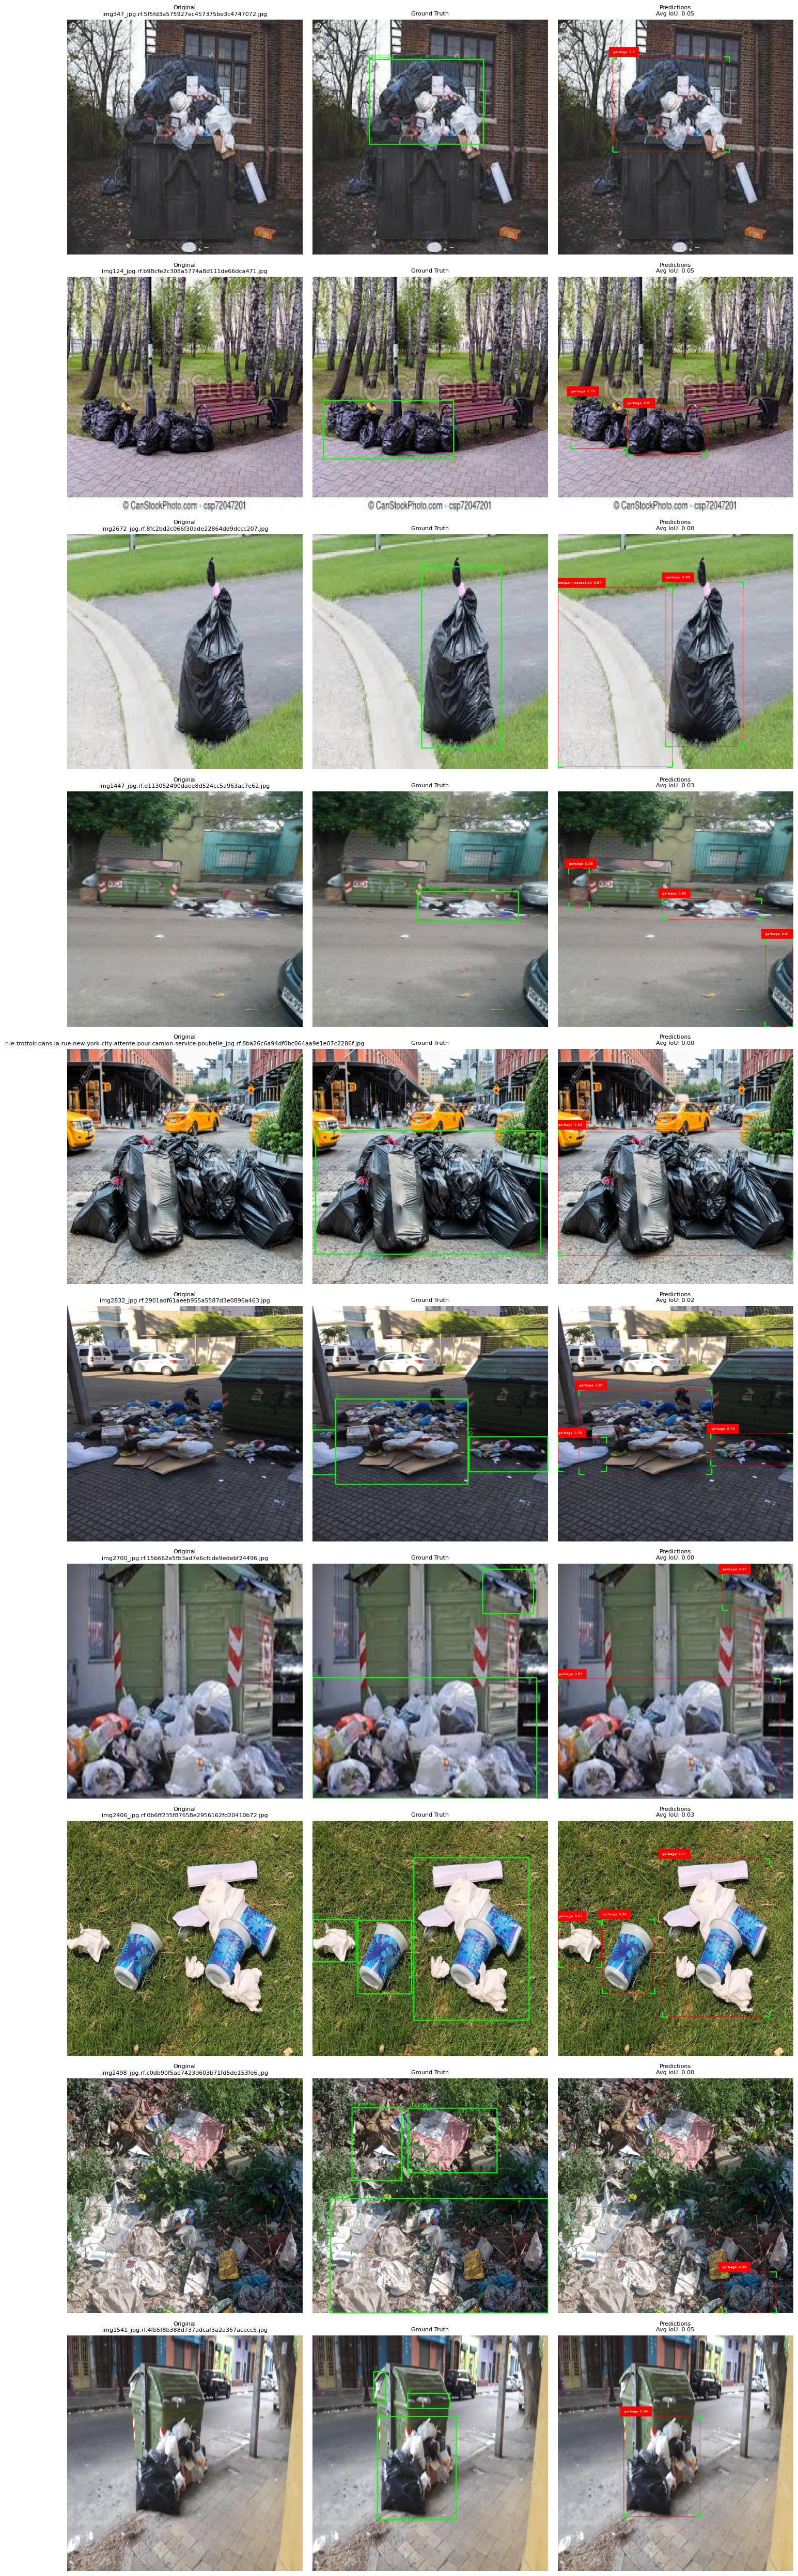

In [ ]:
images_dir = "../content/drive/MyDrive/Datasets/GarbageDetection/valid/images"
labels_dir = "../content/drive/MyDrive/Datasets/GarbageDetection/valid/labels"

plot_comparison_grid(yolo_model, images_dir, labels_dir, class_labels)

# Обнаружение мусора в видео (Real-Time Garbage Detection)

В предыдущем разделе мы использовали модель, которая обнаруживает мусор на изображениях. Теперь мы используем ее для обнаружения мусора в видео.

Здесь мы будем использовать функцию 'cv2.VideoCapture()' для захвата видеокадров и цикл while для их непрерывной обработки.

In [ ]:
# Инициализация модели
model = YOLO("/content/runs/detect/train/weights/best.pt")
classNames = ['0', 'c', 'garbage', 'garbage_bag', 'sampah-detection', 'trash']

# Пути к файлам
input_video_path = "/content/GarbageDetector/Media/garbage1.mp4"
output_video_path = "/content/processed_garbage.mp4"

# Открываем видео
cap = cv2.VideoCapture(input_video_path)
if not cap.isOpened():
    raise ValueError("Не удалось открыть видео файл")

# Получаем параметры видео
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Создаем VideoWriter для сохранения результата
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

# Обработка видео
frame_count = 0
print("Начата обработка видео...")

while cap.isOpened():
    success, img = cap.read()
    if not success:
        break

    # Детекция объектов
    results = model(img, stream=True)
    for r in results:
        boxes = r.boxes
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            w, h = x2 - x1, y2 - y1

            conf = math.ceil((box.conf[0] * 100)) / 100
            cls = int(box.cls[0])

            if conf > 0.1:
                cvzone.cornerRect(img, (x1, y1, w, h), t=2)
                cvzone.putTextRect(img, f'{classNames[cls]} {conf}',
                                 (max(0, x1), max(35, y1)), scale=1, thickness=1)

    # Записываем кадр в выходное видео
    out.write(img)
    frame_count += 1

    # Выводим прогресс каждые 50 кадров
    if frame_count % 50 == 0:
        print(f"Обработано кадров: {frame_count}")

cap.release()
out.release()
print(f"Обработка завершена! Сохранено {frame_count} кадров")

# Создаем ссылку для скачивания
os.system(f'ln -s "{output_video_path}" "/content/processed_video.mp4"')
files.download("/content/processed_video.mp4")

## Функция

In [ ]:
def process_video_with_yolo(input_video_path, model_path, class_names, conf_threshold=0.1):
    """
    Обрабатывает видео с помощью YOLO модели и сохраняет результат

    Параметры:
        input_video_path: путь к входному видео
        model_path: путь к файлу модели .pt
        class_names: список имен классов
        conf_threshold: порог уверенности для детекции (по умолчанию 0.1)
    """
    # Инициализация модели
    model = YOLO(model_path)

    # Создаем путь для выходного видео
    base, ext = os.path.splitext(input_video_path)
    output_video_path = f"{base}_processed{ext}"

    # Открываем видео
    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        raise ValueError(f"Не удалось открыть видео файл: {input_video_path}")

    # Получаем параметры видео
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Создаем VideoWriter для сохранения результата
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

    # Обработка видео
    frame_count = 0
    print(f"Начата обработка видео: {input_video_path}...")

    while cap.isOpened():
        success, img = cap.read()
        if not success:
            break

        # Детекция объектов
        results = model(img, stream=True)
        for r in results:
            boxes = r.boxes
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0]
                x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
                w, h = x2 - x1, y2 - y1

                conf = math.ceil((box.conf[0] * 100)) / 100
                cls = int(box.cls[0])

                if conf > conf_threshold:
                    cvzone.cornerRect(img, (x1, y1, w, h), t=2)
                    cvzone.putTextRect(img, f'{class_names[cls]} {conf}',
                                     (max(0, x1), max(35, y1)), scale=1, thickness=1)

        # Записываем кадр в выходное видео
        out.write(img)
        frame_count += 1

        # Выводим прогресс каждые 50 кадров
        if frame_count % 50 == 0:
            print(f"Обработано кадров: {frame_count}")

    cap.release()
    out.release()
    print(f"Обработка завершена! Сохранено {frame_count} кадров в файл: {output_video_path}")

    # Создаем ссылку для скачивания
    download_path = output_video_path.replace(os.path.dirname(output_video_path), "/content")
    os.system(f'ln -s "{output_video_path}" "{download_path}"')
    files.download(download_path)

    return output_video_path

In [ ]:
model_path = "/content/runs/detect/train/weights/best.pt"

## Видео тест 1

In [ ]:
processed_video = process_video_with_yolo(
    input_video_path="/content/GarbageDetector/Media/garbage1.mp4",
    model_path=model_path,
    class_names=classNames,
    conf_threshold=0.1
)

## Видео тест 2

In [ ]:
processed_video = process_video_with_yolo(
    input_video_path="/content/GarbageDetector/Media/garbage2.mp4",
    model_path=model_path,
    class_names=classNames,
    conf_threshold=0.1
)

## Видео тест 3

In [ ]:
processed_video = process_video_with_yolo(
    input_video_path="/content/GarbageDetector/Media/garbage3.mp4",
    model_path=model_path,
    class_names=classNames,
    conf_threshold=0.1
)

# Вывод

Обнаружение мусора необходимо для поддержания чистоты окружающей среды и улучшения процессов утилизации отходов. В этом проекте мы продемонстрировали, как создать систему обнаружения мусора на базе Python, используя YOLO и OpenCV. Мы рассмотрели две версии: одну, которая обнаруживает мусор на одном изображении, и другую, которая позволяет обнаруживать его на видео в режиме реального времени.
Этот проект демонстрирует возможности компьютерного зрения и глубокого обучения для мониторинга окружающей среды и закладывает основу для разработки более сложных систем управления отходами.